# Rabi frequency plot using mpl
## Originally q2.py. Turning into ipynb 

(120, 100)
[0.06666667 0.13333333 0.43333333 0.675      0.83333333 0.95
 0.83333333 0.70833333 0.35833333 0.15       0.075      0.15833333
 0.4        0.59166667 0.825      0.93333333 0.925      0.66666667
 0.31666667 0.13333333 0.04166667 0.16666667 0.30833333 0.60833333
 0.88333333 0.95       0.85833333 0.58333333 0.31666667 0.125
 0.075      0.125      0.38333333 0.71666667 0.86666667 0.95833333
 0.8        0.6        0.3        0.11666667 0.05       0.16666667
 0.475      0.7        0.91666667 0.94166667 0.85833333 0.525
 0.3        0.06666667 0.05       0.16666667 0.425      0.7
 0.88333333 0.95833333 0.8        0.48333333 0.25833333 0.15
 0.09166667 0.20833333 0.44166667 0.66666667 0.86666667 0.95
 0.83333333 0.64166667 0.25833333 0.10833333 0.08333333 0.25
 0.41666667 0.7        0.9        0.91666667 0.73333333 0.475
 0.25833333 0.08333333 0.05       0.275      0.59166667 0.775
 0.93333333 0.89166667 0.75833333 0.44166667 0.13333333 0.10833333
 0.06666667 0.3        0.51666667 0

[ 0.49882946  0.44206013  0.05039997 -1.64420339]
The pi pulse length is 9.920640415031354 microseconds.
The error in pi pulse length is 0.006388674430876483 microseconds.


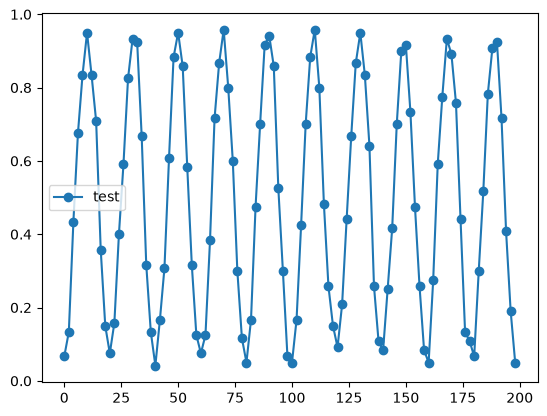

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

#Load txt file
data = np.loadtxt('qiti-iqc-Yb-rabi-data.txt', delimiter='\t')
print(data.shape)

#Take average of columns
averages=np.mean(data, axis=0)
print(averages)
print(averages.shape)

#plot stuff
steps=np.arange(0, 200, 2)
print(steps)
plt.plot(steps, averages, marker='o', label='test')


def functionone(t, offset, amp, freq, phase):
    return offset+amp*np.sin(2*np.pi*freq*t + phase)

p0=[averages.mean(), (averages.max()-averages.min())/2, 1/(20), -np.pi/2]
popt, pcov = scipy.optimize.curve_fit(functionone, steps, averages, p0)
print(popt)
fit_freq=popt[2]
pulse = 0.5/fit_freq
print(f"The pi pulse length is {pulse} microseconds.")

#calculate errors
perr = np.sqrt(np.diag(pcov))
freq_error = perr[2]
pulse_error = (0.5/(fit_freq**2) )*freq_error

print(f"The error in pi pulse length is {pulse_error} microseconds.")
plt.legend()
plt.show()